# Habitat ObjectNav Environment Profiling

**Goal:** Characterize the Habitat ObjectNav environment runtime — step latency, reset latency, resolution scaling, and episode difficulty statistics.

| Property | Value |
|----------|-------|
| Split | val (~2000 episodes, ~36 scenes) |
| Sensors | RGB-D + GPS + Compass |
| Resolutions | 64x64, 128x128, 256x256 |
| Output | `output/comparison/habitat_env_profiling.json` |

---
## 1. Setup

In [1]:
import os, json, gzip, time, subprocess
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt

import habitat
import habitat_sim
from habitat.config import read_write

# Project paths
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent.parent.parent
os.chdir(project_root)

SCENE_DIR = project_root / "data" / "scene_datasets" / "hm3d"
DATA_DIR = project_root / "data" / "datasets" / "objectnav" / "hm3d" / "objectnav_hm3d_v2"

print(f"Project root: {project_root}")
print(f"SCENE_DIR:    {SCENE_DIR} (exists: {SCENE_DIR.exists()})")
print(f"DATA_DIR:     {DATA_DIR} (exists: {DATA_DIR.exists()})")
print(f"habitat-sim:  {habitat_sim.__version__}")
print(f"habitat-lab:  {habitat.__version__}")

for split_name in ["minival", "val", "train"]:
    split_dir = SCENE_DIR / split_name
    if split_dir.exists():
        n = len(list(split_dir.rglob("*.glb")))
        print(f"  {split_name}: {n} scene files")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring


Project root: /pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA
SCENE_DIR:    /pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/data/scene_datasets/hm3d (exists: True)
DATA_DIR:     /pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/data/datasets/objectnav/hm3d/objectnav_hm3d_v2 (exists: True)
habitat-sim:  0.3.3
habitat-lab:  0.3.3
  minival: 10 scene files
  val: 100 scene files


  train: 800 scene files


In [2]:
try:
    result = subprocess.run(
        ["nvidia-smi", "--query-gpu=name,memory.total,memory.used,driver_version",
         "--format=csv,noheader"],
        capture_output=True, text=True, timeout=10,
    )
    print("GPU Info:")
    for line in result.stdout.strip().split("\n"):
        print(f"  {line.strip()}")
except (FileNotFoundError, subprocess.TimeoutExpired):
    print("nvidia-smi not available")

GPU Info:
  NVIDIA H100, 95830 MiB, 27 MiB, 570.195.03


In [3]:
def make_env(resolution, split="val"):
    # Create a Habitat ObjectNav environment at given resolution.
    config = habitat.get_config("benchmark/nav/objectnav/objectnav_hm3d.yaml")
    with read_write(config):
        config.habitat.dataset.split = split
        config.habitat.dataset.data_path = str(
            DATA_DIR / "{split}" / "{split}.json.gz"
        )
        config.habitat.dataset.scenes_dir = "data/scene_datasets"
        scene_cfg = next(SCENE_DIR.rglob("*scene_dataset_config.json"), None)
        if scene_cfg:
            config.habitat.simulator.scene_dataset = str(scene_cfg)
        agent_cfg = config.habitat.simulator.agents.main_agent
        for sensor in ["rgb_sensor", "depth_sensor"]:
            s = getattr(agent_cfg.sim_sensors, sensor)
            s.height = resolution
            s.width = resolution
    return habitat.Env(config=config)


def get_gpu_memory_mb():
    # Read current GPU memory usage via nvidia-smi.
    try:
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=memory.used",
             "--format=csv,noheader,nounits"],
            capture_output=True, text=True, timeout=10,
        )
        return int(result.stdout.strip().split("\n")[0])
    except Exception:
        return float("nan")


def load_val_episodes():
    # Load val episode metadata from per-scene JSON files.
    content_dir = DATA_DIR / "val" / "content"
    episodes = []
    for cf in sorted(content_dir.glob("*.json.gz")):
        with gzip.open(cf, "rt") as f:
            data = json.load(f)
        episodes.extend(data.get("episodes", []))
    return episodes


# Actions for profiling (exclude STOP=0 which ends episodes)
PROFILE_ACTIONS = {1: "MOVE_FORWARD", 2: "TURN_LEFT", 3: "TURN_RIGHT"}

val_episodes = load_val_episodes()
print(f"Loaded {len(val_episodes)} val episodes")

scene_counts = Counter(ep["scene_id"] for ep in val_episodes)
print(f"Across {len(scene_counts)} unique scenes")
print(f"Episodes per scene: min={min(scene_counts.values())}, "
      f"max={max(scene_counts.values())}, "
      f"mean={np.mean(list(scene_counts.values())):.0f}")

Loaded 1000 val episodes
Across 36 unique scenes
Episodes per scene: min=22, max=28, mean=28


---
## 2. Reset Latency

Measure `env.reset()` timing for two cases:
- **Same-scene reset**: next episode uses the same scene mesh (cheap)
- **Scene-transition reset**: next episode triggers a scene mesh reload (expensive)

In [4]:
env = make_env(resolution=256)

gpu_before = get_gpu_memory_mb()

same_scene_times = []
for i in range(20):
    t0 = time.perf_counter()
    obs = env.reset()
    t1 = time.perf_counter()
    same_scene_times.append(t1 - t0)

first_scene = os.path.basename(env.current_episode.scene_id)
gpu_after = get_gpu_memory_mb()

print(f"Scene: {first_scene}")
print(f"Same-scene reset (n=20): {np.mean(same_scene_times):.4f} +/- "
      f"{np.std(same_scene_times):.4f} s")
print(f"  median: {np.median(same_scene_times):.4f} s")
print(f"  min: {np.min(same_scene_times):.4f} s, max: {np.max(same_scene_times):.4f} s")
print(f"GPU memory: {gpu_before} -> {gpu_after} MB "
      f"(env uses ~{gpu_after - gpu_before} MB)")

# Print observation space
print(f"\nObservation keys: {sorted(obs.keys())}")
for k in sorted(obs.keys()):
    v = obs[k]
    if hasattr(v, "shape"):
        print(f"  {k}: shape={v.shape} dtype={v.dtype}")
    elif isinstance(v, (int, float, np.integer, np.floating)):
        print(f"  {k}: {type(v).__name__} = {v}")
    else:
        print(f"  {k}: {type(v).__name__}")

env.close()

2026-03-30 06:05:35,595 Initializing dataset ObjectNav-v1


2026-03-30 06:05:39,078 initializing sim Sim-v0


PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[06:05:40:195363]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'hm3d_annotated_basis' : Lighting Layout Attributes 'no_lights' specified in Scene Attributes but does not exist in dataset, so creating default.
[06:05:40:204334]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `data/scene_datasets/hm3d_v0.2/val/00880-Nfvxx8J5NCo/Nfvxx8J5NCo.basis.scn` does not exist.  Aborting load.
[06:05:40:204948]:[Warning]:[Scene] SemanticScene.cpp(124)::loadSemanticSceneDes

Renderer: NVIDIA H100/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 570.195.03
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-broken-buffer-dsa
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-framebuffer-invalidation-wants-draw-binding
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-

Scene: Nfvxx8J5NCo.basis.glb
Same-scene reset (n=20): 0.0160 +/- 0.0080 s
  median: 0.0139 s
  min: 0.0066 s, max: 0.0404 s
GPU memory: 138 -> 325 MB (env uses ~187 MB)

Observation keys: ['compass', 'depth', 'gps', 'objectgoal', 'rgb']
  compass: shape=(1,) dtype=float32
  depth: shape=(256, 256, 1) dtype=float32
  gps: shape=(2,) dtype=float32
  objectgoal: shape=(1,) dtype=int64
  rgb: shape=(256, 256, 3) dtype=uint8


In [5]:
env = make_env(resolution=256)

# Keep first episode per unique scene to force scene transitions
seen_scenes = set()
one_per_scene = []
for ep in env._dataset.episodes:
    if ep.scene_id not in seen_scenes:
        seen_scenes.add(ep.scene_id)
        one_per_scene.append(ep)

print(f"Filtered to {len(one_per_scene)} episodes (1 per scene)")
env._dataset.episodes = one_per_scene
env._setup_episode_iterator()

scene_transition_times = []
scene_names = []
for i in range(len(one_per_scene)):
    t0 = time.perf_counter()
    obs = env.reset()
    t1 = time.perf_counter()
    name = os.path.basename(
        env.current_episode.scene_id
    ).replace(".basis.glb", "")
    scene_transition_times.append(t1 - t0)
    scene_names.append(name)
    print(f"  Scene {i + 1:2d}/{len(one_per_scene)}: "
          f"{t1 - t0:6.3f}s  {name}")

env.close()

print(f"\nScene-transition reset (n={len(scene_transition_times)}):")
print(f"  mean: {np.mean(scene_transition_times):.3f} +/- "
      f"{np.std(scene_transition_times):.3f} s")
print(f"  median: {np.median(scene_transition_times):.3f} s")
print(f"  min: {np.min(scene_transition_times):.3f} s, "
      f"max: {np.max(scene_transition_times):.3f} s")

2026-03-30 06:05:41,985 Initializing dataset ObjectNav-v1


2026-03-30 06:05:45,408 initializing sim Sim-v0


PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
2026-03-30 06:05:46,510 Initializing task ObjectNav-v1


PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[06:05:45:423128]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'hm3d_annotated_basis' : Lighting Layout Attributes 'no_lights' specified in Scene Attributes but does not exist in dataset, so creating default.
[06:05:45:423921]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `data/scene_datasets/hm3d_v0.2/val/00880-Nfvxx8J5NCo/Nfvxx8J5NCo.basis.scn` does not exist.  Aborting load.
[06:05:45:423992]:[Warning]:[Scene] SemanticScene.cpp(124)::loadSemanticSceneDescriptor : SSD File Naming Issue! Neither SemanticAttributes-provided name :

Renderer: NVIDIA H100/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 570.195.03
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-broken-buffer-dsa
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-framebuffer-invalidation-wants-draw-binding
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-

...

ticSceneDescriptor : SSD Load Failure! File with SemanticAttributes-provided name `data/scene_datasets/hm3d_v0.2/val/00847-bCPU9suPUw9/bCPU9suPUw9.basis.scn` exists but failed to load.
[06:06:34:364477]:[Warning]:[Sim] Simulator.cpp(595)::instanceStageForSceneAttributes : The active scene does not contain semantic annotations : activeSemanticSceneID_ = 0
PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring


Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-broken-buffer-dsa
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-framebuffer-invalidation-wants-draw-binding
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits
  Scene 35/36:  1.908s  wcojb4TFT35


PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[06:06:34:591637]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `data/scene_datasets/hm3d_v0.2/val/00802-wcojb4TFT35/wcojb4TFT35.basis.scn` does not exist.  Aborting load.
[06:06:34:591881]:[Warning]:[Scene] SemanticScene.cpp(124)::loadSemanticSceneDescriptor : SSD File Naming Issue! Neither SemanticAttributes-provided name : `data/scene_datasets/hm3d_v0.2/val/00802-wcojb4TFT35/wcojb4TFT35.basis.scn` nor constructed filename : `data/scene_datasets/hm3d_v0.2/val/00802-wcojb4TFT35/info_semantic.json` exist on disk.
[06:06:34:591907]:[Error]:[Scene] SemanticScene.cpp(140)::loadSeman

Renderer: NVIDIA H100/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 570.195.03
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-broken-buffer-dsa
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-framebuffer-invalidation-wants-draw-binding
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-

PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[06:06:36:504420]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `data/scene_datasets/hm3d_v0.2/val/00814-p53SfW6mjZe/p53SfW6mjZe.basis.scn` does not exist.  Aborting load.
[06:06:36:504665]:[Warning]:[Scene] SemanticScene.cpp(124)::loadSemanticSceneDescriptor : SSD File Naming Issue! Neither SemanticAttributes-provided name : `data/scene_datasets/hm3d_v0.2/val/00814-p53SfW6mjZe/p53SfW6mjZe.basis.scn` nor constructed filename : `data/scene_datasets/hm3d_v0.2/val/00814-p53SfW6mjZe/info_semantic.json` exist on disk.
[06:06:36:504690]:[Error]:[Scene] SemanticScene.cpp(140)::loadSeman

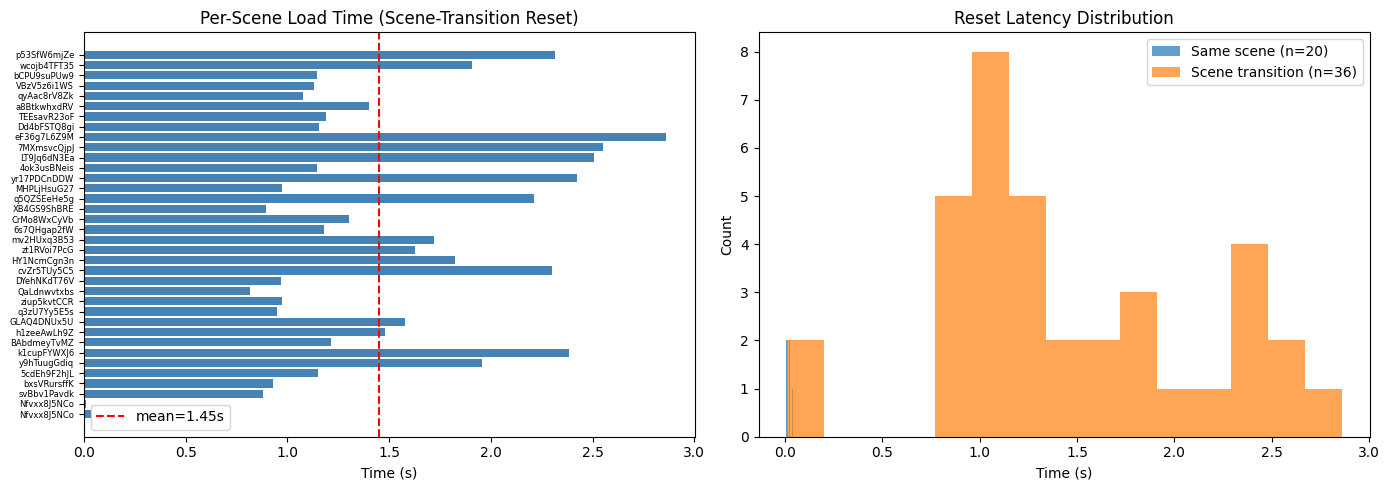

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scene transition times bar chart
axes[0].barh(range(len(scene_transition_times)),
             scene_transition_times, color="steelblue")
axes[0].set_yticks(range(len(scene_names)))
axes[0].set_yticklabels(scene_names, fontsize=6)
axes[0].set_xlabel("Time (s)")
axes[0].set_title("Per-Scene Load Time (Scene-Transition Reset)")
axes[0].axvline(np.mean(scene_transition_times), color="red",
                linestyle="--",
                label=f"mean={np.mean(scene_transition_times):.2f}s")
axes[0].legend()

# Right: distribution comparison
axes[1].hist(same_scene_times, bins=15, alpha=0.7,
             label=f"Same scene (n={len(same_scene_times)})")
axes[1].hist(scene_transition_times, bins=15, alpha=0.7,
             label=f"Scene transition (n={len(scene_transition_times)})")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Count")
axes[1].set_title("Reset Latency Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 3. Step Timing Across Resolutions

Profile `env.step()` at 64x64, 128x128, and 256x256 with random navigation actions (FORWARD, LEFT, RIGHT). Measures RGB-D rendering + GPS/Compass sensor cost.

In [7]:
resolutions = [64, 128, 256]
step_results = {}
n_steps = 100

for res in resolutions:
    print(f"\n{'=' * 50}")
    print(f"Resolution: {res}x{res}")
    print(f"{'=' * 50}")

    gpu_before = get_gpu_memory_mb()
    env = make_env(resolution=res)
    obs = env.reset()
    gpu_after = get_gpu_memory_mb()

    print(f"GPU memory: +{gpu_after - gpu_before} MB")

    step_times = []
    action_types = []

    for i in range(n_steps):
        action = int(np.random.choice(list(PROFILE_ACTIONS.keys())))

        t0 = time.perf_counter()
        obs = env.step(action=action)
        t1 = time.perf_counter()

        step_times.append(t1 - t0)
        action_types.append(PROFILE_ACTIONS[action])

        # Reset if episode ended (unlikely within 100 steps)
        if env.episode_over:
            obs = env.reset()

    env.close()

    # Per-action breakdown
    per_action = {}
    for act_name in PROFILE_ACTIONS.values():
        act_times = [t for t, a in zip(step_times, action_types)
                     if a == act_name]
        if act_times:
            per_action[act_name] = {
                "n": len(act_times),
                "mean_ms": float(np.mean(act_times)) * 1000,
                "std_ms": float(np.std(act_times)) * 1000,
            }

    mean_ms = float(np.mean(step_times)) * 1000
    std_ms = float(np.std(step_times)) * 1000

    step_results[res] = {
        "mean_step_ms": mean_ms,
        "std_step_ms": std_ms,
        "steps_per_sec": 1000.0 / mean_ms,
        "gpu_memory_mb": gpu_after - gpu_before,
        "per_action": per_action,
    }

    print(f"Step: {mean_ms:.2f} +/- {std_ms:.2f} ms  "
          f"({1000 / mean_ms:.0f} steps/s)")
    for act, s in per_action.items():
        print(f"  {act}: {s['mean_ms']:.2f} +/- "
              f"{s['std_ms']:.2f} ms (n={s['n']})")


Resolution: 64x64


2026-03-30 06:06:39,755 Initializing dataset ObjectNav-v1


2026-03-30 06:06:42,895 initializing sim Sim-v0


PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
2026-03-30 06:06:43,983 Initializing task ObjectNav-v1


Renderer: NVIDIA H100/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 570.195.03
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-broken-buffer-dsa
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-framebuffer-invalidation-wants-draw-binding
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-

...

2026-03-30 06:06:51,893 initializing sim Sim-v0


PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring


2026-03-30 06:06:52,955 Initializing task ObjectNav-v1
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[06:06:51:908000]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'hm3d_annotated_basis' : Lighting Layout Attributes 'no_lights' specified in Scene Attributes but does not exist in dataset, so creating default.
[06:06:51:908764]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `data/scene_datasets/hm3d_v0.2/val/00880-Nfvxx8J5NCo/Nfvxx8J5NCo.basis.scn` does not exist.  Aborting load.
[06:06:51:908817]:[Warning]:[Scene] SemanticScene.cpp(124)::loadSemanticSceneDescriptor : SSD File N

Renderer: NVIDIA H100/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 570.195.03
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-broken-buffer-dsa
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-framebuffer-invalidation-wants-draw-binding
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-

Step: 1.52 +/- 0.65 ms  (657 steps/s)
  MOVE_FORWARD: 1.44 +/- 0.24 ms (n=32)
  TURN_LEFT: 1.53 +/- 0.82 ms (n=28)
  TURN_RIGHT: 1.58 +/- 0.73 ms (n=40)


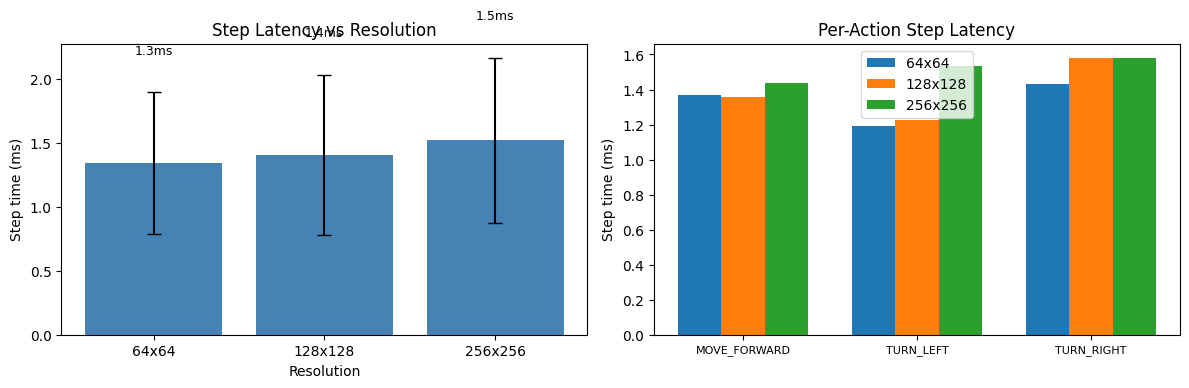

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: aggregate step time by resolution
res_labels = [f"{r}x{r}" for r in resolutions]
means = [step_results[r]["mean_step_ms"] for r in resolutions]
stds = [step_results[r]["std_step_ms"] for r in resolutions]

bars = axes[0].bar(res_labels, means, yerr=stds, capsize=5,
                   color="steelblue")
axes[0].set_xlabel("Resolution")
axes[0].set_ylabel("Step time (ms)")
axes[0].set_title("Step Latency vs Resolution")
for i, (m, s) in enumerate(zip(means, stds)):
    axes[0].text(i, m + s + 0.3, f"{m:.1f}ms", ha="center", fontsize=9)

# Right: per-action breakdown
x = np.arange(len(PROFILE_ACTIONS))
width = 0.25
for i, res in enumerate(resolutions):
    action_means = [
        step_results[res]["per_action"].get(a, {}).get("mean_ms", 0)
        for a in PROFILE_ACTIONS.values()
    ]
    axes[1].bar(x + i * width, action_means, width, label=f"{res}x{res}")

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(list(PROFILE_ACTIONS.values()), fontsize=8)
axes[1].set_ylabel("Step time (ms)")
axes[1].set_title("Per-Action Step Latency")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 4. Difficulty Bucket Analysis

Classify episodes by geodesic distance to goal:
- **Easy**: < 5 m (typically same room)
- **Medium**: 5-10 m (adjacent rooms)
- **Hard**: > 10 m (multi-room navigation)

Bucket                 Count      %   Geo mean    Geo med   Euc mean
----------------------------------------------------------------------
easy (<5m)               521  52.1%      3.19m      3.23m      2.67m
medium (5-10m)           358  35.8%      6.84m      6.59m      5.38m
hard (>10m)              121  12.1%     13.31m     12.56m     10.23m


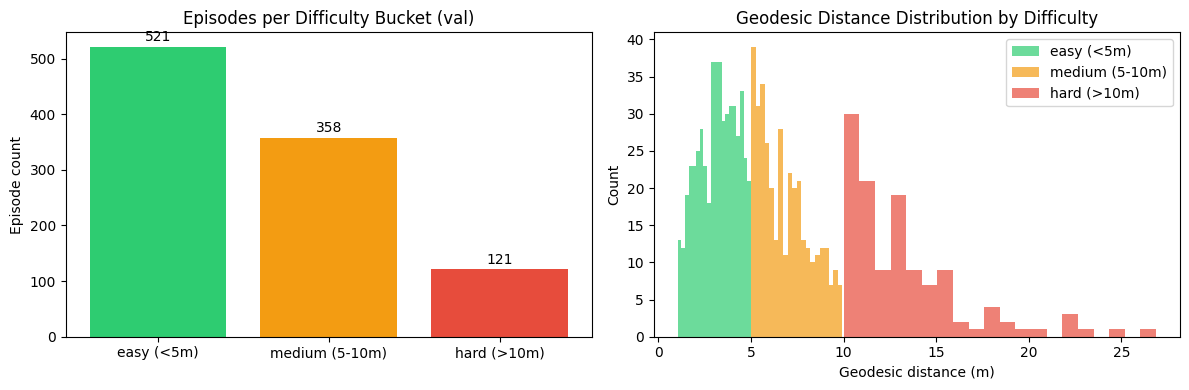

In [9]:
buckets = {"easy (<5m)": [], "medium (5-10m)": [], "hard (>10m)": []}
for ep in val_episodes:
    geo = ep.get("info", {}).get("geodesic_distance", None)
    if geo is None:
        continue
    if geo < 5:
        buckets["easy (<5m)"].append(ep)
    elif geo < 10:
        buckets["medium (5-10m)"].append(ep)
    else:
        buckets["hard (>10m)"].append(ep)

print(f"{'Bucket':<20} {'Count':>7} {'%':>6} "
      f"{'Geo mean':>10} {'Geo med':>10} {'Euc mean':>10}")
print("-" * 70)
total = len(val_episodes)
for name, eps in buckets.items():
    geos = [ep["info"]["geodesic_distance"] for ep in eps]
    eucs = [ep["info"].get("euclidean_distance", float("nan"))
            for ep in eps]
    pct = 100 * len(eps) / total
    print(f"{name:<20} {len(eps):>7} {pct:>5.1f}% "
          f"{np.mean(geos):>9.2f}m {np.median(geos):>9.2f}m "
          f"{np.nanmean(eucs):>9.2f}m")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

names = list(buckets.keys())
counts = [len(buckets[n]) for n in names]
colors = ["#2ecc71", "#f39c12", "#e74c3c"]

axes[0].bar(names, counts, color=colors)
axes[0].set_ylabel("Episode count")
axes[0].set_title("Episodes per Difficulty Bucket (val)")
for i, c in enumerate(counts):
    axes[0].text(i, c + 10, str(c), ha="center", fontsize=10)

for name, color in zip(names, colors):
    geos = [ep["info"]["geodesic_distance"] for ep in buckets[name]]
    axes[1].hist(geos, bins=20, alpha=0.7, color=color, label=name)
axes[1].set_xlabel("Geodesic distance (m)")
axes[1].set_ylabel("Count")
axes[1].set_title("Geodesic Distance Distribution by Difficulty")
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
from habitat.tasks.nav.shortest_path_follower import ShortestPathFollower
import random

rng = random.Random(42)

# Sample episode IDs per bucket
sampled_ids = set()
bucket_sampled_ids = {}
for bucket_name, eps in buckets.items():
    sample = rng.sample(eps, min(5, len(eps)))
    ids = {ep["episode_id"] for ep in sample}
    bucket_sampled_ids[bucket_name] = ids
    sampled_ids |= ids

print(f"Sampled {len(sampled_ids)} episodes for shortest path analysis")

# Create env at low resolution for speed
env = make_env(resolution=64)

# Filter to sampled episodes only
filtered_eps = [ep for ep in env._dataset.episodes
                if ep.episode_id in sampled_ids]
print(f"Matched {len(filtered_eps)} episodes in env dataset")

env._dataset.episodes = filtered_eps
env._setup_episode_iterator()

follower = ShortestPathFollower(
    env.sim, goal_radius=0.2, return_one_hot=False
)

sp_records = []
for i in range(len(filtered_eps)):
    obs = env.reset()
    ep = env.current_episode
    geo = ep.info.get("geodesic_distance", 0) if ep.info else 0

    if geo < 5:
        bucket = "easy (<5m)"
    elif geo < 10:
        bucket = "medium (5-10m)"
    else:
        bucket = "hard (>10m)"

    steps = 0
    while not env.episode_over and steps < 500:
        goal_pos = ep.goals[0].position
        action = follower.get_next_action(goal_pos)
        if action is None:
            break
        obs = env.step(action)
        steps += 1

    metrics = env.get_metrics()
    sp_records.append({
        "episode_id": ep.episode_id,
        "bucket": bucket,
        "geodesic_m": geo,
        "steps": steps,
        "success": float(metrics.get("success", 0)),
        "spl": float(metrics.get("spl", 0)),
    })
    cat = getattr(ep, "object_category", "?")
    succ_str = "OK" if metrics.get("success", 0) > 0 else "FAIL"
    print(f"  [{bucket:<16}] ep={ep.episode_id:<6} cat={cat:<12} "
          f"geo={geo:5.1f}m  steps={steps:3d}  {succ_str}")

env.close()

# Summary per bucket
print(f"\n{'Bucket':<20} {'N':>3} {'Mean steps':>12} {'Success rate':>14}")
print("-" * 55)
for bucket_name in buckets:
    recs = [r for r in sp_records if r["bucket"] == bucket_name]
    if recs:
        mean_steps = np.mean([r["steps"] for r in recs])
        sr = np.mean([r["success"] for r in recs])
        print(f"{bucket_name:<20} {len(recs):>3} "
              f"{mean_steps:>11.1f} {sr:>13.0%}")

Sampled 6 episodes for shortest path analysis


2026-03-30 06:06:54,132 Initializing dataset ObjectNav-v1


2026-03-30 06:06:57,358 initializing sim Sim-v0


PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring2026-03-30 06:06:58,375 Initializing task ObjectNav-v1


Renderer: NVIDIA H100/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 570.195.03
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-broken-buffer-dsa
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-framebuffer-invalidation-wants-draw-binding
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-

...

PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
[06:08:26:398487]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `data/scene_datasets/hm3d_v0.2/val/00823-7MXmsvcQjpJ/7MXmsvcQjpJ.basis.scn` does not exist.  Aborting load.
[06:08:26:398567]:[Warning]:[Scene] SemanticScene.cpp(124)::loadSemanticSceneDescriptor : SSD File Naming Issue! Neither SemanticAttributes-provided name : `data/scene_datasets/hm3d_v0.2/val/00823-7MXmsvcQjpJ/7MXmsvcQjpJ.basis.scn` nor constructed filename : `data/scene_datasets/hm3d_v0.2/val/00823-7MXmsvcQjpJ/info_semantic.json` exist o

    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-broken-buffer-dsa
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-framebuffer-invalidation-wants-draw-binding
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits
  [medium (5-10m)  ] ep=0      cat=chair        geo=  7.6m  steps=  1  FAIL


  [medium (5-10m)  ] ep=4      cat=sofa         geo=  7.7m  steps= 60  OK


  [easy (<5m)      ] ep=3      cat=chair        geo=  3.9m  steps= 48  OK
  [easy (<5m)      ] ep=5      cat=plant        geo=  2.4m  steps=  1  FAIL


  [easy (<5m)      ] ep=1      cat=sofa         geo=  3.9m  steps= 45  OK

Bucket                 N   Mean steps   Success rate
-------------------------------------------------------
easy (<5m)           106        32.7           25%
medium (5-10m)        81        54.9           28%
hard (>10m)           29        66.7           48%


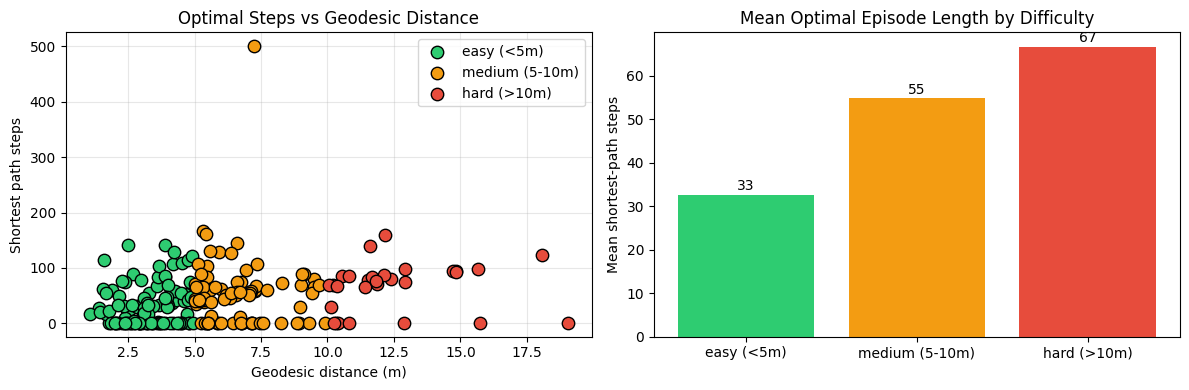

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bucket_names = list(buckets.keys())
colors = ["#2ecc71", "#f39c12", "#e74c3c"]

# Left: scatter — steps vs geodesic distance
for name, color in zip(bucket_names, colors):
    recs = [r for r in sp_records if r["bucket"] == name]
    geos = [r["geodesic_m"] for r in recs]
    steps = [r["steps"] for r in recs]
    axes[0].scatter(geos, steps, c=color, s=80, label=name,
                    edgecolors="black", zorder=3)

axes[0].set_xlabel("Geodesic distance (m)")
axes[0].set_ylabel("Shortest path steps")
axes[0].set_title("Optimal Steps vs Geodesic Distance")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: bar chart of mean steps per bucket
mean_steps_list = []
for name in bucket_names:
    recs = [r for r in sp_records if r["bucket"] == name]
    mean_steps_list.append(
        np.mean([r["steps"] for r in recs]) if recs else 0
    )

axes[1].bar(bucket_names, mean_steps_list, color=colors)
axes[1].set_ylabel("Mean shortest-path steps")
axes[1].set_title("Mean Optimal Episode Length by Difficulty")
for i, m in enumerate(mean_steps_list):
    axes[1].text(i, m + 1, f"{m:.0f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

---
## 5. Summary

In [12]:
results = {
    "reset_latency": {
        "same_scene_mean_s": float(np.mean(same_scene_times)),
        "same_scene_std_s": float(np.std(same_scene_times)),
        "scene_transition_mean_s": float(np.mean(scene_transition_times)),
        "scene_transition_std_s": float(np.std(scene_transition_times)),
        "n_unique_scenes": len(scene_transition_times),
        "gpu_env_memory_mb": int(gpu_after - gpu_before),
    },
    "step_timing": {
        str(res): {
            "mean_step_ms": step_results[res]["mean_step_ms"],
            "std_step_ms": step_results[res]["std_step_ms"],
            "steps_per_sec": step_results[res]["steps_per_sec"],
            "gpu_memory_mb": step_results[res]["gpu_memory_mb"],
        }
        for res in resolutions
    },
    "difficulty_buckets": {
        name: {
            "n_episodes": len(eps),
            "pct": round(100 * len(eps) / len(val_episodes), 1),
            "geodesic_mean_m": round(float(np.mean(
                [e["info"]["geodesic_distance"] for e in eps]
            )), 2),
            "geodesic_median_m": round(float(np.median(
                [e["info"]["geodesic_distance"] for e in eps]
            )), 2),
            "mean_shortest_path_steps": round(float(np.mean(
                [r["steps"] for r in sp_records if r["bucket"] == name]
            )), 1) if any(
                r["bucket"] == name for r in sp_records
            ) else None,
        }
        for name, eps in buckets.items()
    },
    "shortest_path_records": sp_records,
    "environment_config": {
        "sensors": "RGB-D + GPS + Compass + ObjectGoal",
        "action_space": "STOP, MOVE_FORWARD(0.25m), TURN_LEFT(30deg), TURN_RIGHT(30deg)",
        "max_episode_steps": 500,
        "success_distance_m": 1.0,
        "agent_height_m": 0.88,
        "agent_radius_m": 0.18,
    },
}

# Print summary
print("=" * 70)
print("HABITAT OBJECTNAV ENVIRONMENT PROFILE")
print("=" * 70)

print("\n--- Reset Latency ---")
print(f"  Same-scene:       "
      f"{np.mean(same_scene_times)*1000:.1f} ms  (n=20)")
print(f"  Scene-transition: "
      f"{np.mean(scene_transition_times):.2f} s   "
      f"(n={len(scene_transition_times)} scenes)")

print("\n--- Step Latency ---")
header = f"  {'Resolution':<12} {'Mean':>10} {'Std':>10} {'Steps/s':>10} {'GPU MB':>10}"
print(header)
for res in resolutions:
    r = step_results[res]
    print(f"  {res}x{res:<8} {r['mean_step_ms']:>9.2f}ms "
          f"{r['std_step_ms']:>9.2f}ms "
          f"{r['steps_per_sec']:>9.0f} "
          f"{r['gpu_memory_mb']:>9d}")

print("\n--- Difficulty Buckets ---")
print(f"  {'Bucket':<20} {'Count':>7} {'Geo mean':>10} {'SP steps':>10}")
for name, eps in buckets.items():
    geo_mean = np.mean([e["info"]["geodesic_distance"] for e in eps])
    recs = [r for r in sp_records if r["bucket"] == name]
    sp_mean = np.mean([r["steps"] for r in recs]) if recs else float("nan")
    print(f"  {name:<20} {len(eps):>7} "
          f"{geo_mean:>9.2f}m {sp_mean:>9.1f}")

# Save JSON
output_path = project_root / "output" / "comparison" / "habitat_env_profiling.json"
output_path.parent.mkdir(parents=True, exist_ok=True)
with open(output_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"\nResults saved to {output_path}")

HABITAT OBJECTNAV ENVIRONMENT PROFILE

--- Reset Latency ---
  Same-scene:       16.0 ms  (n=20)
  Scene-transition: 1.45 s   (n=36 scenes)

--- Step Latency ---
  Resolution         Mean        Std    Steps/s     GPU MB
  64x64            1.34ms      0.55ms       744       211
  128x128           1.41ms      0.63ms       709       211
  256x256           1.52ms      0.65ms       657       212

--- Difficulty Buckets ---
  Bucket                 Count   Geo mean   SP steps
  easy (<5m)               521      3.19m      32.7
  medium (5-10m)           358      6.84m      54.9
  hard (>10m)              121     13.31m      66.7

Results saved to /pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/output/comparison/habitat_env_profiling.json
